In [35]:
import pandas as pd
import seaborn
import seaborn as sns
import xgboost
from catboost import CatBoostRegressor

from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,KFold
import numpy as np
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
import lightgbm
from sklearn.linear_model import LinearRegression,Ridge,Lasso
import optuna
from sklearn.model_selection import cross_val_score,cross_validate,cross_val_predict


In [212]:
def load_data():
    X = pd.read_csv("StudentPerformanceFactors.csv")
    #X=X.dropna()
    y = X["Exam_Score"]
    X.drop(columns=["Exam_Score"], inplace=True)
    return X,y
X,y = load_data()
X


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female


<Axes: xlabel='Exam_Score', ylabel='Count'>

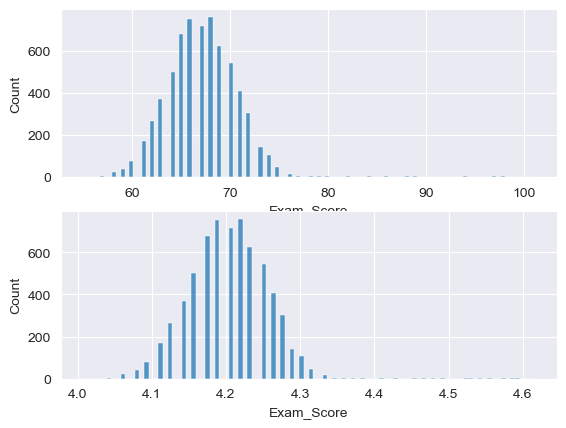

In [128]:
X,y=load_data()
fig,axs = plt.subplots(2,1)
sns.histplot(y,ax=axs[0])
sns.histplot(np.log(y),ax=axs[1])



R2 Score: 0.816373650874696


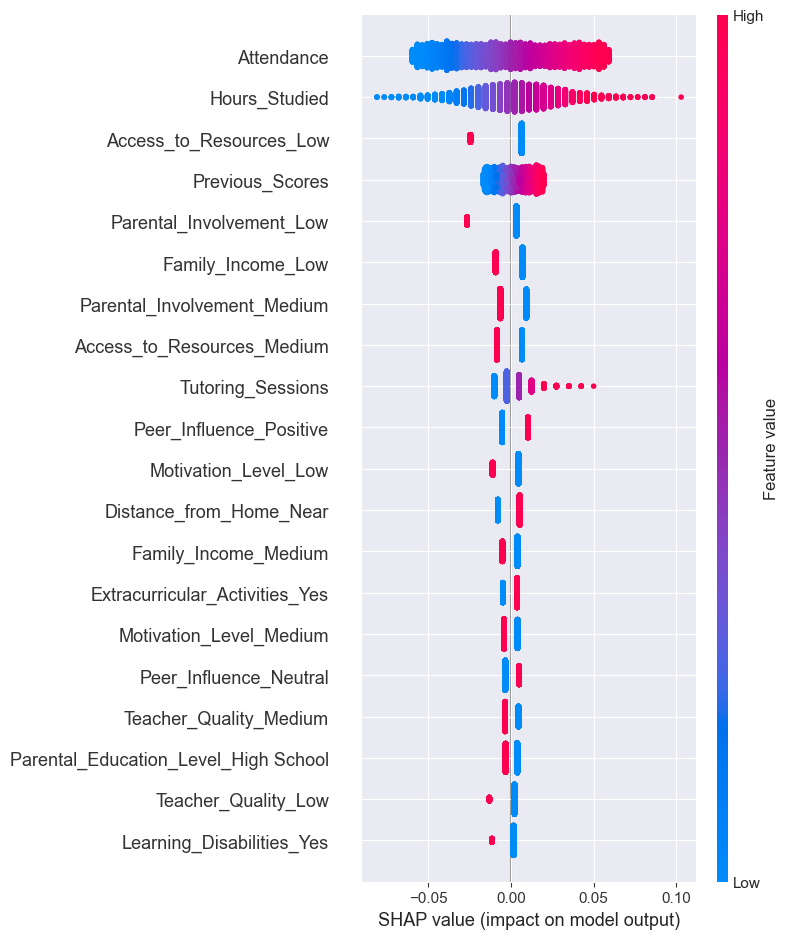

,feature,coef
0,Hours_Studied,0.0262340624
1,Attendance,0.0342531752
2,Sleep_Hours,-0.0001575939
3,Previous_Scores,0.0104612751
4,Tutoring_Sessions,0.0092372612
5,Physical_Activity,0.0030229530
6,Parental_Involvement_Low,-0.0298317967
7,Parental_Involvement_Medium,-0.0157339856
8,Access_to_Resources_Low,-0.0310033785
9,Access_to_Resources_Medium,-0.0151930398


In [218]:
import shap
X,y=load_data()
y = np.log(y)
pd.options.display.float_format = '{:.10f}'.format

categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False,drop="first")
encoded = encoder.fit_transform(X[categorical_columns])
X.drop(columns=categorical_columns,inplace=True)
encoded_names = encoder.get_feature_names_out()
X = pd.concat(
    [X, pd.DataFrame(encoded, columns=encoded_names, index=X.index)],
    axis=1
)
scaler = StandardScaler()
X[numeric] = scaler.fit_transform(X[numeric])

X.columns = X.columns.astype(str)
X,X_test,y,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lm = LinearRegression()
lm.fit(X,y)
preds = lm.predict(X_test)
r2 = r2_score(y_test,preds)
print(f'R2 Score: {r2}')
coefs = pd.DataFrame({"feature": X.columns, "coef": lm.coef_})

explainer = shap.LinearExplainer(lm, X)
shap_values = explainer(X)
shap.summary_plot(shap_values)

coefs

<Axes: xlabel='Sleep_Hours', ylabel='Exam_Score'>

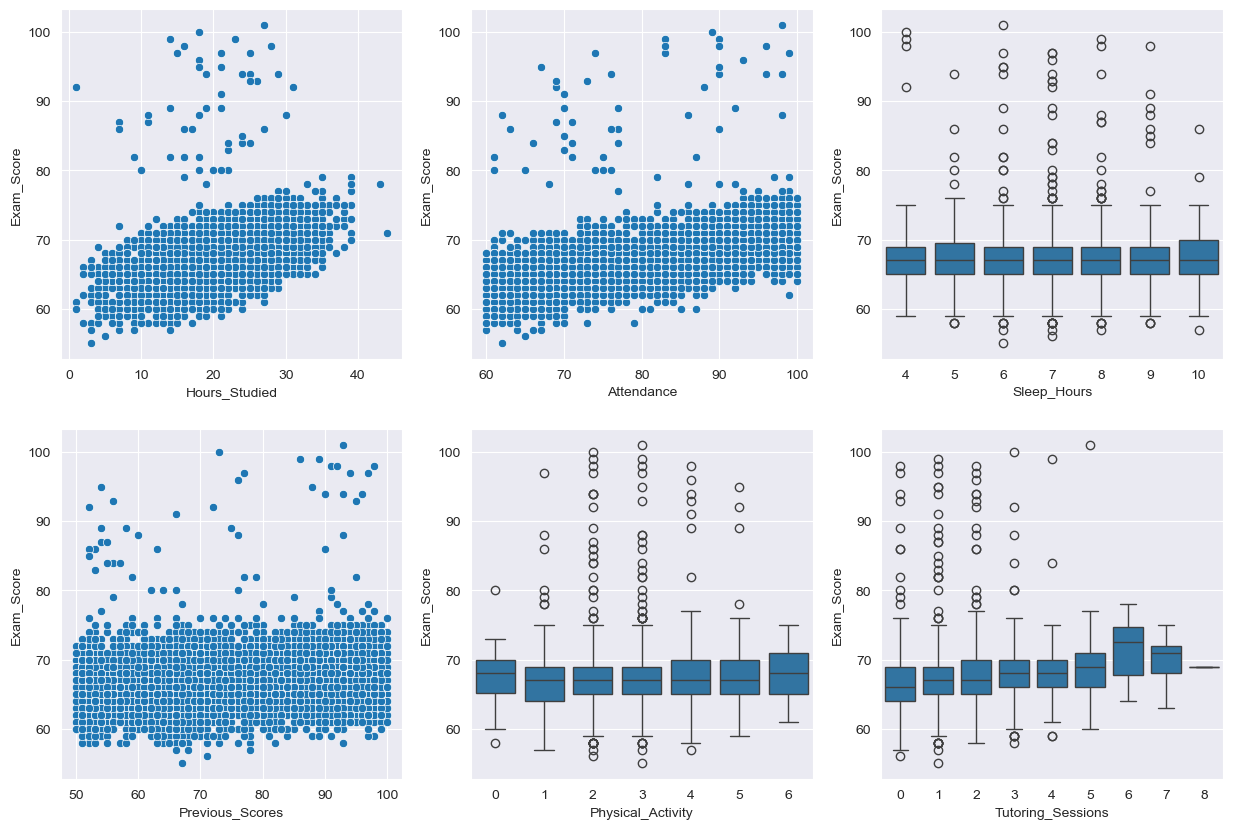

In [242]:
students = pd.read_csv("StudentPerformanceFactors.csv")

fig,axs = plt.subplots(ncols=3,nrows=2,figsize=(15,10))
sns.scatterplot(data=students,x="Hours_Studied",y="Exam_Score",ax=axs[0,0])
sns.scatterplot(data=students,x="Attendance",y="Exam_Score",ax=axs[0,1])
sns.scatterplot(data=students,x="Previous_Scores",y="Exam_Score",ax=axs[1,0])
sns.boxplot(data=students,x="Physical_Activity",y="Exam_Score",ax=axs[1,1])
sns.boxplot(data=students,x="Tutoring_Sessions",y="Exam_Score",ax=axs[1,2])
sns.boxplot(data=students,x="Sleep_Hours",y="Exam_Score",ax=axs[0,2])

[0]	validation_0-rmse:0.05481
[100]	validation_0-rmse:0.03157
[200]	validation_0-rmse:0.02764
[300]	validation_0-rmse:0.02630
[400]	validation_0-rmse:0.02575
[500]	validation_0-rmse:0.02560
[593]	validation_0-rmse:0.02560
R2 full 0.7787833465455567 


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

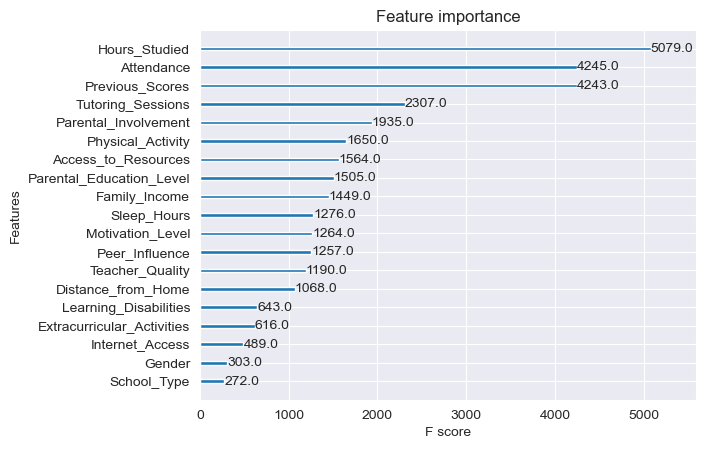

In [203]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include="object").columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model = XGBRegressor(n_estimators=1500,learning_rate=0.02,enable_categorical=True,reg_lambda=10,random_state=42,early_stopping_rounds = 50)
model.fit(X_train,y_train,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model.predict(X_test)

resid = preds-y_test
r2 = r2_score(y_test,preds)


print(f'R2 full {r2} ')

resid = y_test-preds
xgboost.plot_importance(model)
#sns.scatterplot(x=preds,y=y_test,hue  =resid)

## CAT

In [149]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model_cat =CatBoostRegressor(use_best_model=True,early_stopping_rounds=50)
model_cat.fit(X_train,y_train,cat_features=categorical_columns,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model_cat.predict(X_test)
r2_test=r2_score(y_test,preds)
preds_full =model_cat.predict(X)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


Learning rate set to 0.06476
0:	learn: 0.0550409	test: 0.0535739	best: 0.0535739 (0)	total: 175ms	remaining: 2m 54s
100:	learn: 0.0274468	test: 0.0257615	best: 0.0257615 (100)	total: 2.61s	remaining: 23.3s
200:	learn: 0.0250650	test: 0.0244240	best: 0.0244240 (200)	total: 5.76s	remaining: 22.9s
300:	learn: 0.0238397	test: 0.0241730	best: 0.0241730 (300)	total: 7.94s	remaining: 18.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.02416945792
bestIteration = 308

Shrink model to first 309 iterations.
R2 test 0.8060765144087181 
R2 full 0.8147388505358416 
RMSE test 0.02298183338790844 
RMSE full 0.024090301142334496 


## LGBM

In [153]:

X,y =  load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
params = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
model = lightgbm.LGBMRegressor(**params,random_state=42,early_stopping_rounds = 50,n_estimators=5000)
model.fit(X_train,y_train,categorical_feature=categorical_columns,eval_set=[(X_validation,y_validation)])
preds = model.predict(X_test)
preds_full = model.predict(X)
r2 = r2_score(y_test,preds)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


[LightGBM] [Warning] feature_fraction is set=0.7206082609076269, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7206082609076269
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Warning] feature_fraction is set=0.7206082609076269, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7206082609076269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 4624, number of used features: 19
[LightGBM] [Warning] feature_fraction is set=0.7206082609076269, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7206082609076269
[LightGBM] [Warning] early_stopping_round is set=50, 

In [222]:
X,y = load_data()
X=X.dropna()
X

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female


In [292]:
X,y =  load_data()
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X[categorical_columns] = X[categorical_columns].astype("category")

paramsXGB = {
        "n_estimators":3000,
        "max_depth":3,
        "gamma":1.4,
        "subsample":0.8,
    "learning_rate":0.01
    }
params_lgbm = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
X,X_val,y,y_val = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)
xgb = XGBRegressor(**paramsXGB,random_state=42,enable_categorical=True,early_stopping_rounds=50)
cat = CatBoostRegressor(random_state=42,use_best_model=True,early_stopping_rounds=50)
lgbm = lightgbm.LGBMRegressor(**params_lgbm,random_state=42,use_best_model=True,early_stopping_rounds=50,verbosity=-1)
print(np.mean(cross_validate(cat,X,y,params={"cat_features": categorical_columns,"eval_set":[(X_val,y_val)],"verbose":500})["test_score"]))
print(np.mean(cross_validate(xgb,X,y,params={"eval_set":[(X_val,y_val)],"verbose":0})["test_score"]))
print(np.mean(cross_validate(lgbm,X,y,params={"eval_set":[(X_val,y_val)]})["test_score"]))

0.6919242032667917
